In [1]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Wilson_disease_dataset.csv",index_col=0)
df = df.reset_index(drop=True)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               60000 non-null  int64  
 1   Sex                               60000 non-null  object 
 2   Ceruloplasmin Level               53975 non-null  float64
 3   Copper in Blood Serum             53869 non-null  float64
 4   Free Copper in Blood Serum        54067 non-null  float64
 5   Copper in Urine                   53967 non-null  float64
 6   ALT                               53889 non-null  float64
 7   AST                               54138 non-null  float64
 8   Total Bilirubin                   54120 non-null  float64
 9   Albumin                           54023 non-null  float64
 10  Alkaline Phosphatase (ALP)        53935 non-null  float64
 11  Prothrombin Time / INR            53983 non-null  float64
 12  Gamm

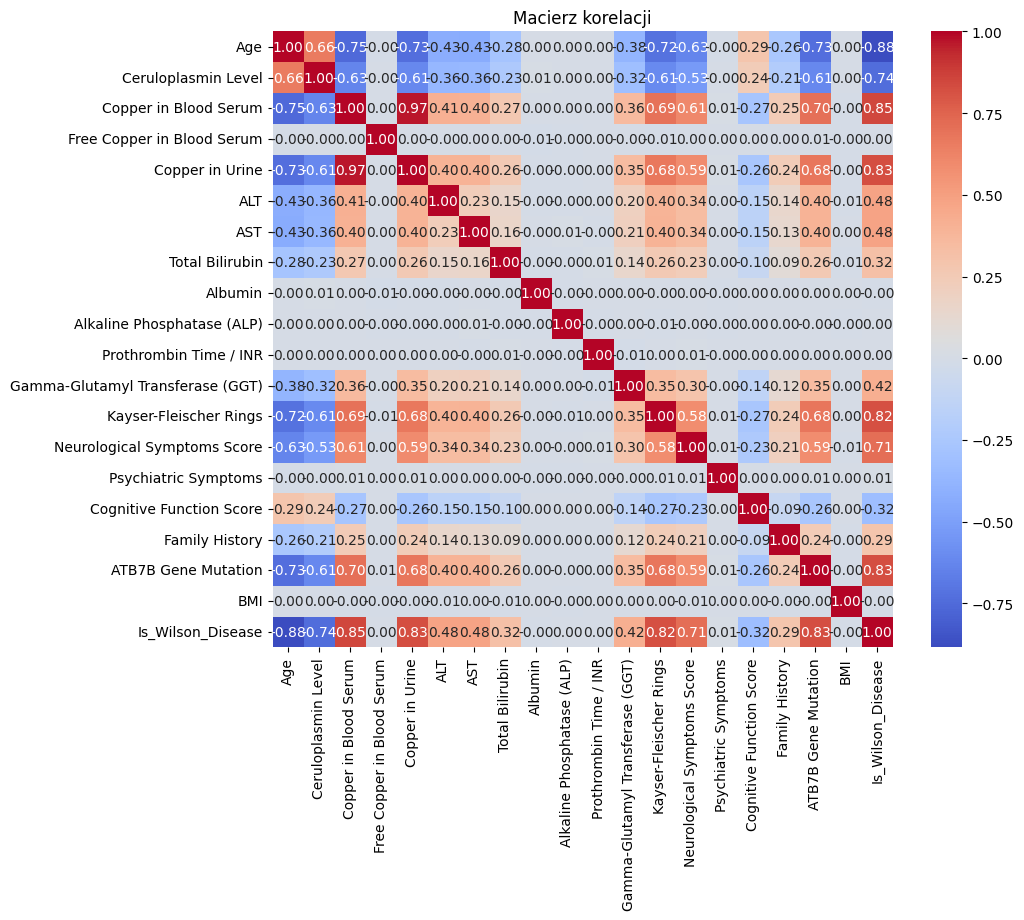

In [4]:
correlation_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Macierz korelacji")
plt.show()
# Albumin, ALP, INR, Psychiatric Symptoms, and BMI are likely weakly associated with the diagnosis of the disease (we will also verify this using classifiers)

In [5]:
print(df.isnull().sum())

Age                                    0
Sex                                    0
Ceruloplasmin Level                 6025
Copper in Blood Serum               6131
Free Copper in Blood Serum          5933
Copper in Urine                     6033
ALT                                 6111
AST                                 5862
Total Bilirubin                     5880
Albumin                             5977
Alkaline Phosphatase (ALP)          6065
Prothrombin Time / INR              6017
Gamma-Glutamyl Transferase (GGT)    5935
Kayser-Fleischer Rings                 0
Neurological Symptoms Score         6119
Psychiatric Symptoms                   0
Cognitive Function Score            5948
Family History                         0
ATB7B Gene Mutation                    0
Region                                 0
Socioeconomic Status                   0
Alcohol Use                            0
BMI                                    0
Is_Wilson_Disease                      0
dtype: int64


In [6]:
# Missing values are imputed with the median
missing_columns=['Ceruloplasmin Level','Copper in Blood Serum','Free Copper in Blood Serum','Copper in Urine','ALT','AST','Total Bilirubin','Albumin','Alkaline Phosphatase (ALP)', 'Prothrombin Time / INR','Gamma-Glutamyl Transferase (GGT)','Neurological Symptoms Score','Cognitive Function Score']
for col in missing_columns:
    df[col] = df[col].fillna(df[col].median())

In [7]:
# Data normalization excluding binary and object-type columns
notnorm_cols=['Sex','Kayser-Fleischer Rings','Psychiatric Symptoms','Family History','ATB7B Gene Mutation','Region','Socioeconomic Status','Alcohol Use','Is_Wilson_Disease']
def NormalizeData(df, notnorm_cols):
    df = df.copy()
    cols = [col for col in df.columns if col not in notnorm_cols]
    for col in cols:
        min_val = df[col].min()
        max_val = df[col].max()
        df[col] = (df[col] - min_val) / (max_val - min_val + (max_val == min_val))
    return df
normalized_df= NormalizeData(df, notnorm_cols)

In [8]:
# Encoding non-numeric data
label_encoders = {}
for col in normalized_df.select_dtypes(include=['object', 'bool']).columns:
    le = LabelEncoder()
    normalized_df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [9]:
normalized_df.head()

,Age,Sex,Ceruloplasmin Level,Copper in Blood Serum,Free Copper in Blood Serum,Copper in Urine,ALT,AST,Total Bilirubin,Albumin,...,Neurological Symptoms Score,Psychiatric Symptoms,Cognitive Function Score,Family History,ATB7B Gene Mutation,Region,Socioeconomic Status,Alcohol Use,BMI,Is_Wilson_Disease
0,0.140625,0,0.227433,0.576528,0.477657,0.561059,0.590776,0.579737,0.397564,0.349924,...,0.473863,1,0.590757,1,1,3,1,0,0.328155,1
1,0.250000,0,0.222950,0.520496,0.503542,0.417940,0.302946,0.552369,0.268510,0.489660,...,0.542241,0,0.743723,1,1,2,2,0,0.705292,1
2,0.406250,1,0.237403,0.651069,0.463196,0.589792,0.423471,0.607740,0.660319,0.735508,...,0.434137,1,0.413494,1,1,3,0,1,0.374213,1
3,0.218750,1,0.287489,0.561096,0.235412,0.612125,0.469863,0.768792,0.425643,0.593339,...,0.378538,1,0.510782,1,1,3,0,0,0.954166,1
4,0.390625,0,0.231144,0.578678,0.668576,0.490903,0.556854,0.641483,0.703122,0.480319,...,0.454576,0,0.429489,1,1,0,1,1,0.672155,1


In [10]:
# 70:30 train-test split
def split(data, test_size, random_state):
    random.seed(random_state)
    rows = list(data.index)      
    random.shuffle(rows)

    count = int(len(data) * test_size)
    test_ids = rows[:count]
    train_ids = rows[count:]

    train_set = data.loc[train_ids].reset_index(drop=True)
    test_set = data.loc[test_ids].reset_index(drop=True)

    return train_set, test_set

trainSet, testSet = split(normalized_df, 0.3,42)

In [11]:
trainSet.head()

,Age,Sex,Ceruloplasmin Level,Copper in Blood Serum,Free Copper in Blood Serum,Copper in Urine,ALT,AST,Total Bilirubin,Albumin,...,Neurological Symptoms Score,Psychiatric Symptoms,Cognitive Function Score,Family History,ATB7B Gene Mutation,Region,Socioeconomic Status,Alcohol Use,BMI,Is_Wilson_Disease
0,0.718750,1,0.350487,0.376727,0.726747,0.232793,0.446312,0.380263,0.480014,0.317032,...,0.332940,0,0.622300,1,0,1,1,0,0.109456,0
1,0.125000,0,0.254446,0.693311,0.541418,0.682448,0.531772,0.595065,0.441645,0.549369,...,0.465947,0,0.606168,1,1,0,2,0,0.689425,1
2,0.203125,0,0.256243,0.581316,0.492739,0.577842,0.856853,0.490021,0.191913,0.649151,...,0.407224,1,0.470400,1,1,3,1,0,0.345548,1
3,0.578125,0,0.362598,0.273406,0.477657,0.267815,0.390977,0.415875,0.438319,0.492259,...,0.393931,1,0.665905,1,0,1,2,0,0.631741,0
4,0.734375,1,0.687107,0.320281,0.391521,0.290087,0.382582,0.415875,0.358952,0.378939,...,0.356286,0,0.609640,0,0,1,1,1,0.796095,0


In [12]:
testSet.head()

,Age,Sex,Ceruloplasmin Level,Copper in Blood Serum,Free Copper in Blood Serum,Copper in Urine,ALT,AST,Total Bilirubin,Albumin,...,Neurological Symptoms Score,Psychiatric Symptoms,Cognitive Function Score,Family History,ATB7B Gene Mutation,Region,Socioeconomic Status,Alcohol Use,BMI,Is_Wilson_Disease
0,0.640625,0,0.487272,0.421067,0.502399,0.425866,0.412144,0.368542,0.431260,0.763960,...,0.315952,1,0.607675,0,0,3,2,1,0.149084,0
1,0.062500,0,0.245344,0.626237,0.275400,0.384225,0.418501,0.664298,0.604776,0.389299,...,0.571985,0,0.478577,1,0,1,0,1,0.249595,1
2,0.359375,0,0.368569,0.519175,0.490402,0.530152,0.454334,0.537782,0.572756,0.383649,...,0.479740,0,0.449825,0,1,0,1,1,0.712124,1
3,0.765625,0,0.407475,0.347459,0.450447,0.329892,0.216729,0.470051,0.515125,0.639293,...,0.337679,0,0.649598,0,0,1,0,1,0.176184,0
4,0.156250,1,0.280933,0.634381,0.517263,0.675021,0.403035,0.415875,0.303739,0.465986,...,0.600994,0,0.536499,1,0,0,2,0,0.114461,1


In [13]:
def calculate_class_means(train_df):
    class_stats = {}
    classes = train_df['Is_Wilson_Disease'].unique()
    for class_label in classes:
        class_data = train_df[train_df['Is_Wilson_Disease'] == class_label].drop(columns='Is_Wilson_Disease')
        means = class_data.mean()
        margins = class_data.std()
        class_stats[class_label] = (means, margins)
    return class_stats

def calculate_class_medians(train_df):
    class_stats = {}
    classes = train_df['Is_Wilson_Disease'].unique()
    for class_label in classes:
        class_data = train_df[train_df['Is_Wilson_Disease'] == class_label].drop(columns='Is_Wilson_Disease')
        
        medians = class_data.median()
        q75 = class_data.quantile(0.75)
        q25 = class_data.quantile(0.25)
        iqr = q75 - q25
        
        margins = iqr
        
        class_stats[class_label] = (medians, margins)
    return class_stats

In [14]:
def soft_set_membership(test_obj, class_stats,weights):
    memberships = {}
    for class_label, (means, margins) in class_stats.items():
        match_count = 0
        total_features = len(means)
        for i, feature_val in enumerate(test_obj):
            mean_val = means.iloc[i]
            margin = margins.iloc[i]
            if (mean_val - margin) <= feature_val <= (mean_val + margin):
                match_count += weights[i]
        memberships[class_label] = match_count
    return memberships

In [15]:
def classify_with_method(train_df, test_df, calculate_stats_func, weights):
    class_stats = calculate_stats_func(train_df)

    correct = 0
    total = len(test_df)
    classification_table = []

    feature_columns = [col for col in test_df.columns if col != 'Is_Wilson_Disease']

    for _, row in test_df.iterrows():
        true_class = row['Is_Wilson_Disease']
        test_data = row[feature_columns].values

        memberships = soft_set_membership(test_data, class_stats, weights)

        predicted_class = max(memberships, key=memberships.get)

        if predicted_class == true_class:
            correct += 1

        classification_table.append({
            "true_class": true_class,
            "predicted_class": predicted_class,
            "probabilities": memberships
        })

    accuracy = correct / total
    return classification_table, accuracy

In [16]:
def result(weights):
    table1, acc1 = classify_with_method(trainSet, testSet, calculate_class_means, weights)
    table2, acc2 = classify_with_method(trainSet, testSet, calculate_class_medians, weights)

    results_table1 = pd.DataFrame(table1)
    prob_cols = pd.DataFrame(results_table1['probabilities'].tolist())
    prob_cols.columns = ['isWilsonsdisease_False', 'isWilsonsdisease_True']
    results_table1 = pd.concat([results_table1.drop(columns=['probabilities']), prob_cols], axis=1)
    
    results_table2 = pd.DataFrame(table2)
    prob_cols = pd.DataFrame(results_table2['probabilities'].tolist())
    prob_cols.columns = ['isWilsonsdisease_False', 'isWilsonsdisease_True']
    results_table2 = pd.concat([results_table2.drop(columns=['probabilities']), prob_cols], axis=1)

    print(f"Mean-based table: \n{results_table1.head(10).to_string(index=False)}")
    print(f"Median-based table: \n{results_table2.head(10).to_string(index=False)}")
    print(f"Mean-based accuracy: {acc1:.2%}")
    print(f"Median-based accuracy: {acc2:.2%}")

In [17]:
weights_0 = [1/23] * 23

In [18]:
result(weights_0)

Mean-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                0.521739               0.391304
        1.0                1                0.478261               0.565217
        1.0                1                0.521739               0.782609
        0.0                0                0.608696               0.434783
        1.0                1                0.478261               0.608696
        1.0                1                0.434783               0.695652
        0.0                0                0.608696               0.521739
        1.0                1                0.521739               0.652174
        0.0                0                0.565217               0.391304
        0.0                0                0.695652               0.347826
Median-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                0.91

In [19]:
weights_1 = [
    0.2265,  # Age
    0.0989,  # Sex
    0.0123,  # Ceruloplasmin Level
    0.0443,  # Copper in Blood Serum
    0.0170,  # Free Copper in Blood Serum
    0.0761,  # Copper in Urine
    0.0744,  # ALT
    0.0132,  # AST
    0.0126,  # Total Bilirubin
    0.0233,  # Albumin
    0.0549,  # Alkaline Phosphatase (ALP)
    0.0165,  # Prothrombin Time / INR
    0.0142,  # Gamma-Glutamyl Transferase (GGT)
    0.0084,  # Kayser-Fleischer Rings
    0.1192,  # Neurological Symptoms Score
    0.0394,  # Psychiatric Symptoms
    0.0040,  # Cognitive Function Score
    0.0061,  # Family History
    0.1065,  # ATB7B Gene Mutation
    0.0119,  # Region
    0.0010,  # Socioeconomic Status
    0.0061,  # Alcohol Use
    0.0131   # BMI
]

In [20]:
result(weights_1)

Mean-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.6167                 0.2831
        1.0                1                  0.4202                 0.4827
        1.0                1                  0.2806                 0.9218
        0.0                0                  0.7398                 0.3520
        1.0                1                  0.4644                 0.5912
        1.0                1                  0.2280                 0.4465
        0.0                0                  0.4292                 0.3211
        1.0                1                  0.3831                 0.4966
        0.0                0                  0.5239                 0.3050
        0.0                0                  0.8066                 0.1974
Median-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.

In [21]:
weights_2 = [
    0.1588,  # Age
    0.0176,  # Sex
    0.0210,  # Ceruloplasmin Level
    0.0173,  # Copper in Blood Serum
    0.0618,  # Free Copper in Blood Serum
    0.0076,  # Copper in Urine
    0.0664,  # ALT
    0.0351,  # AST
    0.0190,  # Total Bilirubin
    0.0244,  # Albumin
    0.0207,  # Alkaline Phosphatase (ALP)
    0.0246,  # Prothrombin Time / INR
    0.0081,  # Gamma-Glutamyl Transferase (GGT)
    0.1121,  # Kayser-Fleischer Rings
    0.1038,  # Neurological Symptoms Score
    0.0482,  # Psychiatric Symptoms
    0.0747,  # Cognitive Function Score
    0.0277,  # Family History
    0.0165,  # ATB7B Gene Mutation
    0.0757,  # Region
    0.0361,  # Socioeconomic Status
    0.0119,  # Alcohol Use
    0.0110   # BMI
]

In [22]:
result(weights_2)

Mean-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.7057                 0.3323
        1.0                1                  0.4222                 0.4803
        1.0                1                  0.4463                 0.7154
        0.0                0                  0.7652                 0.4284
        1.0                1                  0.3511                 0.6603
        1.0                1                  0.3422                 0.5344
        0.0                0                  0.6582                 0.4706
        1.0                0                  0.5075                 0.4812
        0.0                0                  0.6650                 0.3847
        0.0                0                  0.8400                 0.3329
Median-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.

In [23]:
weights_3 = [
    0.1112,  # Age
    0.0365,  # Sex
    0.0381,  # Ceruloplasmin Level
    0.0506,  # Copper in Blood Serum
    0.0728,  # Free Copper in Blood Serum
    0.0383,  # Copper in Urine
    0.0245,  # ALT
    0.0462,  # AST
    0.0164,  # Total Bilirubin
    0.0023,  # Albumin
    0.0695,  # Alkaline Phosphatase (ALP)
    0.0152,  # Prothrombin Time / INR
    0.0262,  # Gamma-Glutamyl Transferase (GGT)
    0.0667,  # Kayser-Fleischer Rings
    0.0348,  # Neurological Symptoms Score
    0.0218,  # Psychiatric Symptoms
    0.0185,  # Cognitive Function Score
    0.0395,  # Family History
    0.0061,  # ATB7B Gene Mutation
    0.0770,  # Region
    0.0661,  # Socioeconomic Status
    0.0690,  # Alcohol Use
    0.0527   # BMI
]

In [24]:
result(weights_3)

Mean-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.5195                 0.3009
        1.0                1                  0.4674                 0.5392
        1.0                1                  0.5249                 0.7569
        0.0                0                  0.7206                 0.4669
        1.0                1                  0.3606                 0.6196
        1.0                1                  0.3804                 0.5975
        0.0                0                  0.5381                 0.4507
        1.0                1                  0.4439                 0.5991
        0.0                0                  0.5299                 0.3864
        0.0                0                  0.6205                 0.2849
Median-based table: 
 true_class  predicted_class  isWilsonsdisease_False  isWilsonsdisease_True
        0.0                0                  0.